In [168]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from scipy import stats
import numpy as np


In [169]:
df= pd.read_csv('../data/training_set_features.csv')

In [170]:
df

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,NaN,NaN
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,NaN,Not Married,Own,NaN,lzgpxyit,"MSA, Not Principle City",0.0,0.0,NaN,NaN
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg


SPRINT 1

Task 1.1: Project Setup and Data Exploration

Ticket 1.1.2: Load and examine the dataset structure


#Import datasets and check dimensions, column types, and missing values

In [171]:
#open the datasets
submission = pd.read_csv("../data/submission_format.csv")
print(submission)
test_features = pd.read_csv("../data/test_set_features.csv")
print(test_features)
train_features = pd.read_csv("../data/training_set_features.csv")
print(train_features)
train_labels = pd.read_csv("../data/training_set_labels.csv")
print (train_labels)



       respondent_id  h1n1_vaccine  seasonal_vaccine
0              26707           0.5               0.7
1              26708           0.5               0.7
2              26709           0.5               0.7
3              26710           0.5               0.7
4              26711           0.5               0.7
...              ...           ...               ...
26703          53410           0.5               0.7
26704          53411           0.5               0.7
26705          53412           0.5               0.7
26706          53413           0.5               0.7
26707          53414           0.5               0.7

[26708 rows x 3 columns]
       respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
0              26707           2.0             2.0                        0.0   
1              26708           1.0             1.0                        0.0   
2              26709           2.0             2.0                        0.0   
3             

In [172]:
#merge the X and Y training datasets 
train_data = train_features.merge(train_labels, on='respondent_id')
train_data.info()
train_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_mo

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,1.0,0.0,0.0,NaN,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,NaN,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [173]:
pd.set_option("display.max_columns", None) # desplay all the columns

In [174]:
print("Dataset dimensions:", train_data.shape) 
print("Column types:\n", train_data.dtypes)
print("Missing values:\n", train_data.isnull().sum())

Dataset dimensions: (26707, 38)
Column types:
 respondent_id                    int64
h1n1_concern                   float64
h1n1_knowledge                 float64
behavioral_antiviral_meds      float64
behavioral_avoidance           float64
behavioral_face_mask           float64
behavioral_wash_hands          float64
behavioral_large_gatherings    float64
behavioral_outside_home        float64
behavioral_touch_face          float64
doctor_recc_h1n1               float64
doctor_recc_seasonal           float64
chronic_med_condition          float64
child_under_6_months           float64
health_worker                  float64
health_insurance               float64
opinion_h1n1_vacc_effective    float64
opinion_h1n1_risk              float64
opinion_h1n1_sick_from_vacc    float64
opinion_seas_vacc_effective    float64
opinion_seas_risk              float64
opinion_seas_sick_from_vacc    float64
age_group                       object
education                       object
race             

Ticket 1.1.3: Create summary statistics for all features

#Generate statistics for numerical and categorical features

In [175]:
print("Numerical Features Summary:")
print(train_data.describe())
print("\nCategorical Features Summary:")
print(train_data.describe(include="object"))

Numerical Features Summary:
       respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
count   26707.000000  26615.000000    26591.000000               26636.000000   
mean    13353.000000      1.618486        1.262532                   0.048844   
std      7709.791156      0.910311        0.618149                   0.215545   
min         0.000000      0.000000        0.000000                   0.000000   
25%      6676.500000      1.000000        1.000000                   0.000000   
50%     13353.000000      2.000000        1.000000                   0.000000   
75%     20029.500000      2.000000        2.000000                   0.000000   
max     26706.000000      3.000000        2.000000                   1.000000   

       behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
count          26499.000000          26688.000000           26665.000000   
mean               0.725612              0.068982               0.825614   
std           

#Check target variable distributions and class balance

In [176]:
# Check the distribution of the 'h1n1_vaccine' target variable
print("H1N1 Vaccine Distribution:")
print(train_data['h1n1_vaccine'].value_counts(normalize=True))

# Check the distribution of the 'seasonal_vaccine' target variable
print("\nSeasonal Vaccine Distribution:")
print(train_data['seasonal_vaccine'].value_counts(normalize=True))

H1N1 Vaccine Distribution:
h1n1_vaccine
0    0.787546
1    0.212454
Name: proportion, dtype: float64

Seasonal Vaccine Distribution:
seasonal_vaccine
0    0.534392
1    0.465608
Name: proportion, dtype: float64


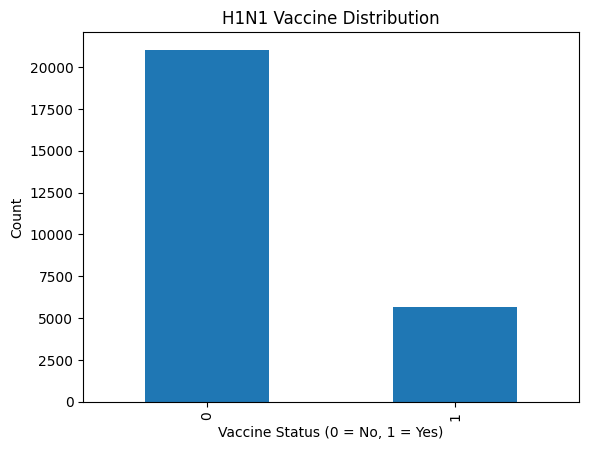

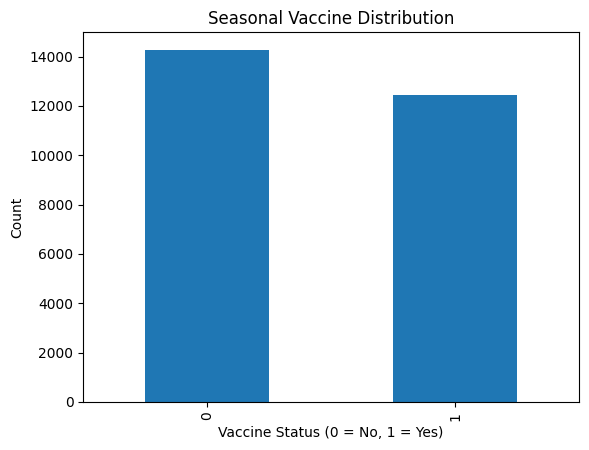

In [177]:
# Plot the distribution for 'h1n1_vaccine'
train_data['h1n1_vaccine'].value_counts().plot(kind='bar', title="H1N1 Vaccine Distribution")
plt.xlabel('Vaccine Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

# Plot the distribution for 'seasonal_vaccine'
train_data['seasonal_vaccine'].value_counts().plot(kind='bar', title="Seasonal Vaccine Distribution")
plt.xlabel('Vaccine Status (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.show()

Task 1.2: Data Cleaning and Preprocessing

Ticket 1.2.1: Handle missing values

#Analyze patterns of missingness and implement appropriate imputation strategies

In [178]:
# Calculate the percentage of missing values for each feature
missing_data = train_data.isnull().sum()
missing_percentage = (missing_data / len(train_data)) * 100

In [179]:
# Print the number of missing values and their percentage
print("Missing Values Count:")
print(missing_data)
print("\nMissing Values Percentage:")
print(missing_percentage)

Missing Values Count:
respondent_id                      0
h1n1_concern                      92
h1n1_knowledge                   116
behavioral_antiviral_meds         71
behavioral_avoidance             208
behavioral_face_mask              19
behavioral_wash_hands             42
behavioral_large_gatherings       87
behavioral_outside_home           82
behavioral_touch_face            128
doctor_recc_h1n1                2160
doctor_recc_seasonal            2160
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
health_insurance               12274
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
opinion_h1n1_sick_from_vacc      395
opinion_seas_vacc_effective      462
opinion_seas_risk                514
opinion_seas_sick_from_vacc      537
age_group                          0
education                       1407
race                               0
sex                                0
income_poverty  

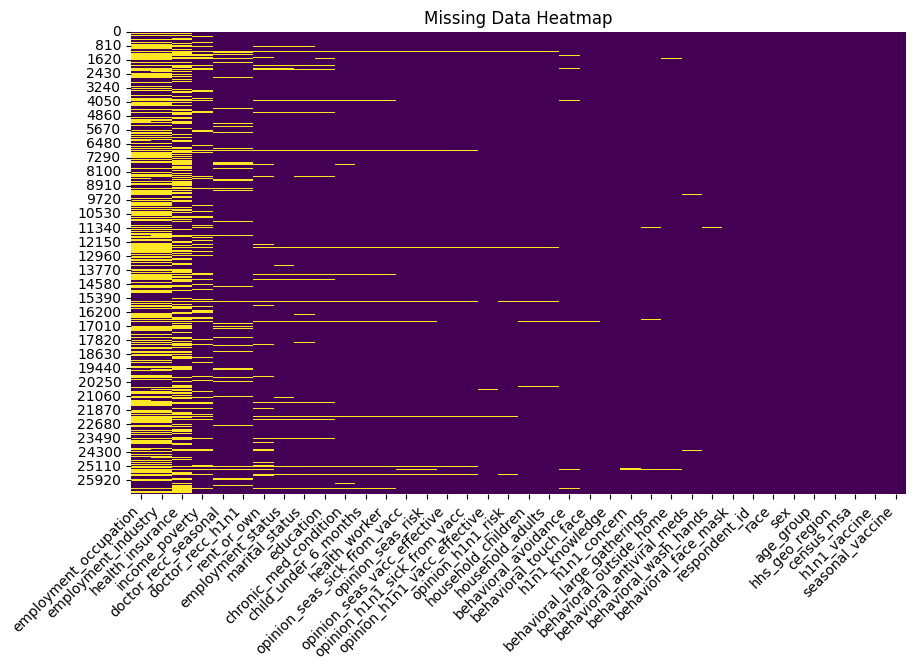

In [180]:
# Visualize missing data using a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(train_data.isnull(), cbar=False, cmap="viridis")
# Sort by missing count
sorted_cols = train_data.isnull().sum().sort_values(ascending=False).index
sns.heatmap(train_data[sorted_cols].isnull(), cbar=False, cmap="viridis")
plt.xticks(rotation=45, ha='right')


plt.title('Missing Data Heatmap')
plt.show()

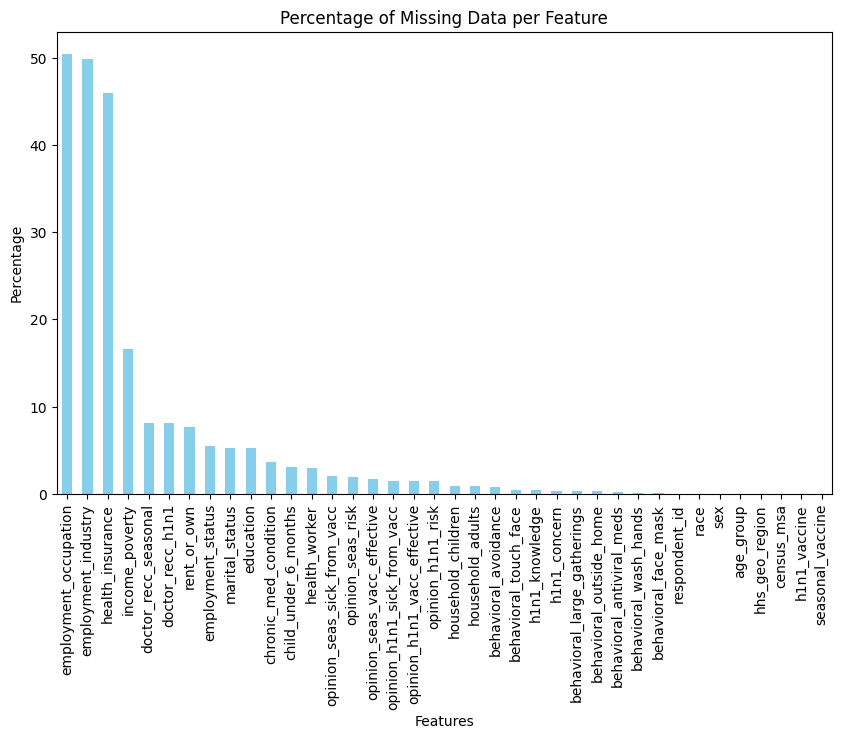

In [181]:
# Visualize the distribution of missing data per column
plt.figure(figsize=(10, 6))
missing_percentage.sort_values(ascending=False).plot(kind='bar', color='skyblue')
plt.title('Percentage of Missing Data per Feature')
plt.ylabel('Percentage')
plt.xlabel('Features')
plt.show()

In [182]:
# 1. Numerical features → Median
# Rationale: Median is robust to outliers and reflects the center of distribution.
numerical_cols = train_data.select_dtypes(include=['float64', 'int64']).columns
for col in numerical_cols:
    if train_data[col].isnull().sum() > 0:
        median_val = train_data[col].median()
        train_data[col] = train_data[col].fillna(median_val)
        print(f"[Imputation] {col}: filled missing values with median = {median_val}")
# 2. Categorical features → Mode
# Rationale: Mode is the most frequent value, assuming majority behavior is missing default.
categorical_cols = train_data.select_dtypes(include='object').columns
for col in categorical_cols:
    if train_data[col].isnull().sum() > 0:
        mode_val = train_data[col].mode()[0]
        train_data[col] = train_data[col].fillna(mode_val)
        print(f"[Imputation] {col}: filled missing values with mode = '{mode_val}'")

# 3. Binary features (if known) → Fill with 0 (No)
# Rationale: In absence of info, assume "No" or 0 if it makes domain sense.
binary_cols = ['health_worker', 'doctor_recc_h1n1', 'doctor_recc_seasonal'] 
for col in binary_cols:
    if col in train_data.columns and train_data[col].isnull().sum() > 0:
        train_data[col] = train_data[col].fillna(0)
        print(f"[Imputation] {col}: filled missing binary values with 0 (assumed 'No')")

# 4. Save imputed data
train_data.to_csv('train_data_imputed.csv', index=False)
print("✅ Data saved as 'train_data_imputed.csv'")




[Imputation] h1n1_concern: filled missing values with median = 2.0
[Imputation] h1n1_knowledge: filled missing values with median = 1.0
[Imputation] behavioral_antiviral_meds: filled missing values with median = 0.0
[Imputation] behavioral_avoidance: filled missing values with median = 1.0
[Imputation] behavioral_face_mask: filled missing values with median = 0.0
[Imputation] behavioral_wash_hands: filled missing values with median = 1.0
[Imputation] behavioral_large_gatherings: filled missing values with median = 0.0
[Imputation] behavioral_outside_home: filled missing values with median = 0.0
[Imputation] behavioral_touch_face: filled missing values with median = 1.0
[Imputation] doctor_recc_h1n1: filled missing values with median = 0.0
[Imputation] doctor_recc_seasonal: filled missing values with median = 0.0
[Imputation] chronic_med_condition: filled missing values with median = 0.0
[Imputation] child_under_6_months: filled missing values with median = 0.0
[Imputation] health_worke

#Document rationale for each imputation decision

- **Numerical columns**: Imputed using median to reduce the impact of outliers and preserve central tendency.
- **Categorical columns**: Imputed using mode (most frequent value), assuming missing entries reflect the most typical response.
- **Binary columns**: Imputed with 0, assuming absence of data indicates "No" or "False" — validated by domain context.


Ticket 1.2.2: Convert categorical variables to appropriate formats

#Apply encoding techniques (one-hot, label, ordinal) based on variable type

In [183]:
train_data

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,55 - 64 Years,< 12 Years,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,fcxhlnwr,xtkaffoo,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,35 - 44 Years,12 Years,White,Male,Below Poverty,Not Married,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,4.0,1.0,2.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,5.0,5.0,4.0,1.0,65+ Years,12 Years,White,Female,Below Poverty,Not Married,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,fcxhlnwr,xtkaffoo,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,3.0,2.0,3.0,1.0,4.0,45 - 54 Years,Some College,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26702,26702,2.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,1.0,5.0,2.0,2.0,65+ Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,qufhixun,Non-MSA,0.0,0.0,fcxhlnwr,xtkaffoo,0,0
26703,26703,1.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,4.0,2.0,2.0,5.0,1.0,1.0,18 - 34 Years,College Graduate,White,Male,"<= $75,000, Above Poverty",Not Married,Rent,Employed,lzgpxyit,"MSA, Principle City",1.0,0.0,fcxhlnwr,cmhcxjea,0,0
26704,26704,2.0,2.0,0.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,4.0,2.0,5.0,4.0,2.0,55 - 64 Years,Some College,White,Female,"<= $75,000, Above Poverty",Not Married,Own,Employed,lzgpxyit,"MSA, Not Principle City",0.0,0.0,fcxhlnwr,xtkaffoo,0,1
26705,26705,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,2.0,2.0,1.0,2.0,18 - 34 Years,Some College,Hispanic,Female,"<= $75,000, Above Poverty",Married,Rent,Employed,lrircsnp,Non-MSA,1.0,0.0,fcxhlnwr,haliazsg,0,0


In [184]:

# Frequency count
for col in ['age_group', 'education', 'race', 'sex', 'income_poverty', 'marital_status', 'rent_or_own', 
            'employment_status', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation']:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 30)


Value counts for age_group:
age_group
65+ Years        6843
55 - 64 Years    5563
45 - 54 Years    5238
18 - 34 Years    5215
35 - 44 Years    3848
Name: count, dtype: int64
------------------------------
Value counts for education:
education
College Graduate    10097
Some College         7043
12 Years             5797
< 12 Years           2363
Name: count, dtype: int64
------------------------------
Value counts for race:
race
White                21222
Black                 2118
Hispanic              1755
Other or Multiple     1612
Name: count, dtype: int64
------------------------------
Value counts for sex:
sex
Female    15858
Male      10849
Name: count, dtype: int64
------------------------------
Value counts for income_poverty:
income_poverty
<= $75,000, Above Poverty    12777
> $75,000                     6810
Below Poverty                 2697
Name: count, dtype: int64
------------------------------
Value counts for marital_status:
marital_status
Married        13555
Not Marri

In [185]:


# Define variable groups
ordinal_cols = ['age_group', 'education', 'income_poverty']
binary_cols = ['sex', 'marital_status', 'rent_or_own']
nominal_cols = ['race', 'hhs_geo_region', 'census_msa', 'employment_industry', 'employment_occupation', 'employment_status']

# Define custom orderings for ordinal columns
age_order = ['18 - 34 Years', '35 - 44 Years', '45 - 54 Years', '55 - 64 Years', '65+ Years']
edu_order = ['< 12 Years', '12 Years', 'Some College', 'College Graduate']
income_order = ['Below Poverty', '<= $75,000, Above Poverty', '> $75,000']

# Apply Ordinal Encoding
ordinal_mapping = OrdinalEncoder(categories=[age_order, edu_order, income_order])
train_data[ordinal_cols] = ordinal_mapping.fit_transform(train_data[ordinal_cols])

# Apply Label Encoding to binary (2-class) categorical variables
label_enc = LabelEncoder()
for col in binary_cols:
    train_data[col] = label_enc.fit_transform(train_data[col])

# One-Hot Encode nominal categorical columns
train_data = pd.get_dummies(train_data, columns=nominal_cols, drop_first=True)

print("Encoding complete. New shape:", df.shape)


Encoding complete. New shape: (26707, 36)


In [186]:
train_data

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,age_group,education,sex,income_poverty,marital_status,rent_or_own,household_adults,household_children,h1n1_vaccine,seasonal_vaccine,race_Hispanic,race_Other or Multiple,race_White,hhs_geo_region_bhuqouqj,hhs_geo_region_dqpwygqj,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Principle City",census_msa_Non-MSA,employment_industry_atmlpfrs,employment_industry_cfqqtusy,employment_industry_dotnnunm,employment_industry_fcxhlnwr,employment_industry_haxffmxo,employment_industry_ldnlellj,employment_industry_mcubkhph,employment_industry_mfikgejo,employment_industry_msuufmds,employment_industry_nduyfdeo,employment_industry_phxvnwax,employment_industry_pxcmvdjn,employment_industry_qnlwzans,employment_industry_rucpziij,employment_industry_saaquncn,employment_industry_vjjrobsf,employment_industry_wlfvacwt,employment_industry_wxleyezf,employment_industry_xicduogh,employment_industry_xqicxuve,employment_occupation_ccgxvspp,employment_occupation_cmhcxjea,employment_occupation_dcjcmpih,employment_occupation_dlvbwzss,employment_occupation_emcorrxb,employment_occupation_haliazsg,employment_occupation_hfxkjkmi,employment_occupation_hodpvpew,employment_occupation_kldqjyjy,employment_occupation_mxkfnird,employment_occupation_oijqvulv,employment_occupation_pvmttkik,employment_occupation_qxajmpny,employment_occupation_rcertsgn,employment_occupation_tfqavkke,employment_occupation_ukymxvdu,employment_occupation_uqqtjvyb,employment_occupation_vlluhbov,employment_occupation_xgwztkwe,employment_occupation_xqwwgdyp,employment_occupation_xtkaffoo,employment_occupation_xzmlyyjv,employment_status_Not in Labor Force,employment_status_Unemployed
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,1.0,2.0,2.0,1.0,2.0,3.0,0.0,0,0.0,1,0,0.0,0.0,0,0,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,4.0,4.0,2.0,4.0,1.0,1.0,1,0.0,1,1,0.0,0.0,0,1,False,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,3.0,1.0,1.0,4.0,1.0,2.0,0.0,3.0,1,1.0,1,0,2.0,0.0,0,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,3.0,3.0,5.0,5.0,4.0,1.0,4.0,1.0,0,0.0,1,1,0.0,0.0,0,1,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

#Encoding summary

Ordinal Encoding (Order Matters)
-age_group  
-education 
-income_poverty

Label Encoding (Binary)
-sex  
-marital_status 
-rent_or_own 


One-Hot Encoding (No Order, Many Categories)
-race  
-hhs_geo_region 
-census_msa 
-employment_industry 
-employment_occupation
-employment_status

Ticket 1.2.3: Check for and handle outliers if necessary

Checking for Numerical Continuous variables


In [ ]:

print(f"Summary before removing outliers for {col}:\n", train_data.describe())

Summary before removing outliers for household_children:
        respondent_id  h1n1_concern  h1n1_knowledge  behavioral_antiviral_meds  \
count   26707.000000  26707.000000    26707.000000                    26707.0   
mean    13353.000000      1.619800        1.261392                        0.0   
std      7709.791156      0.909016        0.617047                        0.0   
min         0.000000      0.000000        0.000000                        0.0   
25%      6676.500000      1.000000        1.000000                        0.0   
50%     13353.000000      2.000000        1.000000                        0.0   
75%     20029.500000      2.000000        2.000000                        0.0   
max     26706.000000      3.000000        2.000000                        0.0   

       behavioral_avoidance  behavioral_face_mask  behavioral_wash_hands  \
count          26707.000000               26707.0                26707.0   
mean               0.727749                   0.0           

In [190]:
# Frequency count
for col in ['h1n1_concern', 'h1n1_knowledge', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk', 'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective', 'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group', 'education', 'income_poverty', 'household_adults', 'household_children']:
    print(f"Value counts for {col}:")
    print(df[col].value_counts())
    print("-" * 30)


Value counts for h1n1_concern:
h1n1_concern
2.0    10575
1.0     8153
3.0     4591
0.0     3296
Name: count, dtype: int64
------------------------------
Value counts for h1n1_knowledge:
h1n1_knowledge
1.0    14598
2.0     9487
0.0     2506
Name: count, dtype: int64
------------------------------
Value counts for opinion_h1n1_vacc_effective:
opinion_h1n1_vacc_effective
4.0    11683
5.0     7166
3.0     4723
2.0     1858
1.0      886
Name: count, dtype: int64
------------------------------
Value counts for opinion_h1n1_risk:
opinion_h1n1_risk
2.0    9919
1.0    8139
4.0    5394
5.0    1750
3.0    1117
Name: count, dtype: int64
------------------------------
Value counts for opinion_h1n1_sick_from_vacc:
opinion_h1n1_sick_from_vacc
2.0    9129
1.0    8998
4.0    5850
5.0    2187
3.0     148
Name: count, dtype: int64
------------------------------
Value counts for opinion_seas_vacc_effective:
opinion_seas_vacc_effective
4.0    11629
5.0     9973
2.0     2206
1.0     1221
3.0     1216
Name: 

In [ ]:
#Check how many unique values do the variables have
for col in float_cols:
    unique_vals = train_data[col].nunique()
    print(f"{col}: {unique_vals} unique values")


h1n1_concern: 4 unique values
h1n1_knowledge: 3 unique values
behavioral_antiviral_meds: 2 unique values
behavioral_avoidance: 2 unique values
behavioral_face_mask: 2 unique values
behavioral_wash_hands: 2 unique values
behavioral_large_gatherings: 2 unique values
behavioral_outside_home: 2 unique values
behavioral_touch_face: 2 unique values
doctor_recc_h1n1: 2 unique values
doctor_recc_seasonal: 2 unique values
chronic_med_condition: 2 unique values
child_under_6_months: 2 unique values
health_worker: 2 unique values
health_insurance: 2 unique values
opinion_h1n1_vacc_effective: 5 unique values
opinion_h1n1_risk: 5 unique values
opinion_h1n1_sick_from_vacc: 5 unique values
opinion_seas_vacc_effective: 5 unique values
opinion_seas_risk: 5 unique values
opinion_seas_sick_from_vacc: 5 unique values
age_group: 5 unique values
education: 4 unique values
income_poverty: 3 unique values
household_adults: 4 unique values
household_children: 4 unique values


--------------------------------------------------
#Keeping the code for detecting and dealing with outliers just in casse here

#Select float64 columns
float_cols = train_data.select_dtypes(include='float64').columns

#Exclude binary float columns (only 2 unique values, because for outlyer analysis we can't use dummies)
non_binary_float_cols = [col for col in float_cols if train_data[col].nunique() > 2]

print("Float columns (excluding binary) for outlier analysis:")
print(non_binary_float_cols)


#Visualizing the outlyers
for col in float_cols:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=train_data[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

for col in float_cols:
    train_data[col].hist(bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    
 #IQR (Interquartile Range) method to flag potential outliers
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers

#Apply across all float columns
for col in float_cols:
    outliers = detect_outliers_iqr(train_data, col)
    print(f"{col}: {len(outliers)} outliers")


columns_with_outliers = ['']

#Apply Winsorization (Capping)
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    data[col] = np.where(data[col] < lower_bound, lower_bound,
                         np.where(data[col] > upper_bound, upper_bound, data[col]))
    return data

#Apply to selected columns
for col in columns_with_outliers:
    train_data = cap_outliers(train_data, col)


#Summary comparison table
#Store before-treatment stats
summary_before = {}

#Recalculate for columns only
for col in columns_with_outliers:
    summary_before[col] = train_data[col].describe()

#After treatment
print("\n=== IMPACT OF OUTLIER TREATMENT ===")
for col in columns_with_outliers:
    print(f"\n {col}")
    print("Before Treatment:")
    print(summary_before[col])
    print("\nAfter Treatment:")
    print(train_data[col].describe())



Summary for outliers analysis:
    We can apply outliers analysis only to continues numerical variables, and since the variables in the dataset are not continuous numerical, I guess we can skip this step. 